# Big Data Analytics — Project 1
## Analyzing Sales Data with Dask

**Dataset:** Sample Sales Data (2,823 rows × 25 columns)  
**Tools:** Dask, Pandas, Scikit-learn, Matplotlib, Seaborn

In [1]:
import dask
from dask.distributed import Client
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


---
## Task 1 — Data Preparation

### 1.1 Load dataset using Dask DataFrames

In [2]:
df = pd.read_csv('data/sales_data_sample.csv', encoding='latin1')
dtypes = df.dtypes.to_dict()

In [3]:
# Load with Dask for parallel processing
ddf = dd.read_csv('data/sales_data_sample.csv', encoding='latin1',dtype=dtypes)

print('Dask DataFrame info:')
print(f'  Number of partitions: {ddf.npartitions}')
print(f'  Columns: {list(ddf.columns)}')
print()

# Compute shape
n_rows = len(ddf)
n_cols = len(ddf.columns)
print(f'  Shape: ({n_rows}, {n_cols})')

# Preview first 5 rows
ddf.head(5)

Dask DataFrame info:
  Number of partitions: 1
  Columns: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

  Shape: (2823, 25)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,<NA>,NYC,NY,10022,USA,<NA>,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,<NA>,Reims,<NA>,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,<NA>,Paris,<NA>,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,<NA>,Pasadena,CA,90003,USA,<NA>,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,<NA>,San Francisco,CA,<NA>,USA,<NA>,Brown,Julie,Medium


### 1.2 Data Cleaning — Missing Values, Outliers, Inconsistencies

Columns with missing values:
              Missing Count  Missing %
ADDRESSLINE2           2521      89.30
STATE                  1486      52.64
POSTALCODE               76       2.69
TERRITORY              1074      38.04


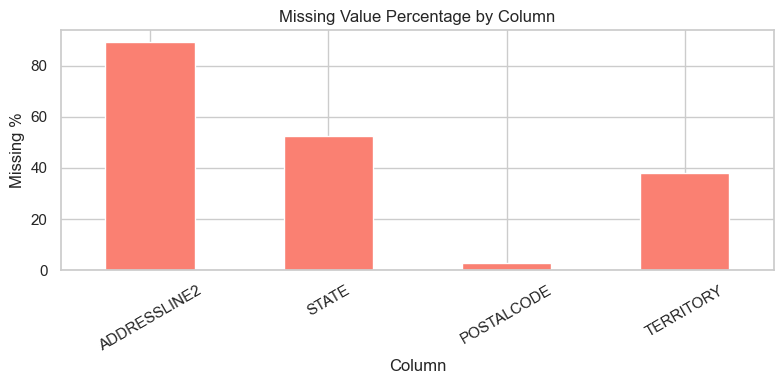

In [4]:
# ── Check missing values ──────────────────────────────────────────────────────
missing = ddf.isnull().sum().compute()
missing_pct = (missing / len(ddf) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

print('Columns with missing values:')
print(missing_df)

# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='bar', ax=ax, color='salmon')
ax.set_title('Missing Value Percentage by Column')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [5]:
# ── Handle missing values ─────────────────────────────────────────────────────
# ADDRESSLINE2 → not critical, fill with 'N/A'
# STATE        → fill with 'Unknown'
# POSTALCODE   → fill with 'Unknown'
# TERRITORY    → fill with 'Unknown'

ddf = ddf.fillna({
    'ADDRESSLINE2': 'N/A',
    'STATE':        'Unknown',
    'POSTALCODE':   'Unknown',
    'TERRITORY':    'Unknown'
})

# Convert ORDERDATE to datetime
ddf['ORDERDATE'] = dd.to_datetime(ddf['ORDERDATE'])

# Verify no missing values remain in key columns
remaining_missing = ddf[['SALES','QUANTITYORDERED','PRICEEACH']].isnull().sum().compute()
print('Missing values in key numeric columns after cleaning:')
print(remaining_missing)
print('\nData types after conversion:')
print(ddf.dtypes)

Missing values in key numeric columns after cleaning:
SALES              0
QUANTITYORDERED    0
PRICEEACH          0
dtype: int64

Data types after conversion:
ORDERNUMBER                float64
QUANTITYORDERED            float64
PRICEEACH                  float64
ORDERLINENUMBER            float64
SALES                      float64
ORDERDATE           datetime64[us]
STATUS                      string
QTR_ID                     float64
MONTH_ID                   float64
YEAR_ID                    float64
PRODUCTLINE                 string
MSRP                       float64
PRODUCTCODE                 string
CUSTOMERNAME                string
PHONE                       string
ADDRESSLINE1                string
ADDRESSLINE2                string
CITY                        string
STATE                       string
POSTALCODE                  string
COUNTRY                     string
TERRITORY                   string
CONTACTLASTNAME             string
CONTACTFIRSTNAME            string


SALES: 81 outliers detected (bounds: [-1253.42, 7964.85])
QUANTITYORDERED: 8 outliers detected (bounds: [3.00, 67.00])
PRICEEACH: 0 outliers detected (bounds: [22.15, 146.71])


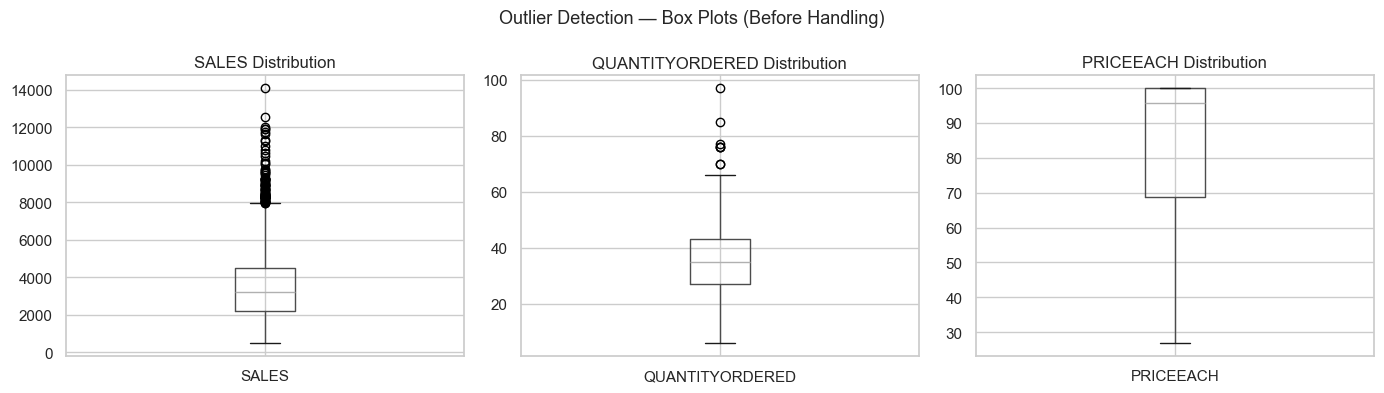

In [6]:
# ── Detect Outliers using IQR on SALES and QUANTITYORDERED ───────────────────
df_pd = ddf.compute()  # bring to pandas for IQR calculation

outlier_bounds = {}
for col in ['SALES', 'QUANTITYORDERED', 'PRICEEACH']:
    Q1 = df_pd[col].quantile(0.25)
    Q3 = df_pd[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_pd[(df_pd[col] < lower) | (df_pd[col] > upper)]
    outlier_bounds[col] = (lower, upper)
    print(f'{col}: {len(outliers)} outliers detected '
          f'(bounds: [{lower:.2f}, {upper:.2f}])')

# Visualize BEFORE handling
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['SALES', 'QUANTITYORDERED', 'PRICEEACH']):
    df_pd.boxplot(column=col, ax=ax)
    ax.set_title(f'{col} Distribution')
plt.suptitle('Outlier Detection — Box Plots (Before Handling)', fontsize=13)
plt.tight_layout()
plt.show()


SALES before Winsorize — min: 482.13, max: 14082.80, mean: 3553.89
SALES after  Winsorize — min: 482.13, max: 7964.85, mean: 3519.25
Remaining SALES outliers after Winsorize: 0

QUANTITYORDERED — 8 outliers kept (genuine bulk orders):
      ORDERNUMBER               CUSTOMERNAME  QUANTITYORDERED     SALES
418         10405                Mini Caravy               97  7964.855
598         10407  The Sharp Gifts Warehouse               76  7964.855
1666        10412      Euro Shopping Channel               70  7964.855
1714        10407  The Sharp Gifts Warehouse               76  7182.000
1995        10405                Mini Caravy               76  7964.855
1996        10419      Salzburg Collectables               70  7964.855
2586        10401    Tekni Collectables Inc.               85  7543.750
2689        10401    Tekni Collectables Inc.               77  7084.000

PRICEEACH — 0 outliers, no action needed.

Dask DataFrame updated with cleaned data. Partitions: 4


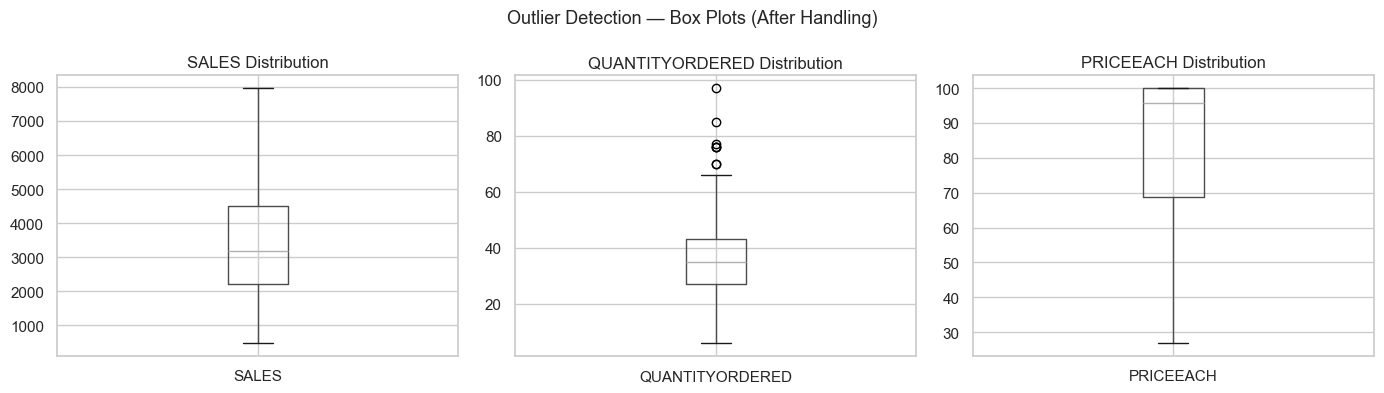

In [7]:
# ── Handle Outliers ───────────────────────────────────────────────────────────
# SALES (81 outliers)      → Winsorize: cap at IQR bounds
#   Reason: large orders are real business events, don't delete them but cap to reduce skew effect on modeling
# QUANTITYORDERED (8 rows) → Keep as-is
#   Reason: only 8 rows, very likely genuine bulk orders
# PRICEEACH (0 outliers)   → No action needed

lower_sales, upper_sales = outlier_bounds['SALES']

print(f'\nSALES before Winsorize — min: {df_pd["SALES"].min():.2f}, '
      f'max: {df_pd["SALES"].max():.2f}, '
      f'mean: {df_pd["SALES"].mean():.2f}')

# Winsorize: clip values at IQR bounds
df_pd['SALES'] = df_pd['SALES'].clip(lower=lower_sales, upper=upper_sales)

print(f'SALES after  Winsorize — min: {df_pd["SALES"].min():.2f}, '
      f'max: {df_pd["SALES"].max():.2f}, '
      f'mean: {df_pd["SALES"].mean():.2f}')

remaining = len(df_pd[
    (df_pd['SALES'] < lower_sales) | (df_pd['SALES'] > upper_sales)
])
print(f'Remaining SALES outliers after Winsorize: {remaining}')

print(f'\nQUANTITYORDERED — 8 outliers kept (genuine bulk orders):')
print(df_pd[df_pd['QUANTITYORDERED'] > outlier_bounds['QUANTITYORDERED'][1]]
      [['ORDERNUMBER', 'CUSTOMERNAME', 'QUANTITYORDERED', 'SALES']])

print(f'\nPRICEEACH — 0 outliers, no action needed.')

# Sync cleaned pandas DataFrame back to Dask
ddf = dd.from_pandas(df_pd, npartitions=4)
print(f'\nDask DataFrame updated with cleaned data. Partitions: {ddf.npartitions}')

# Visualize AFTER handling
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['SALES', 'QUANTITYORDERED', 'PRICEEACH']):
    df_pd.boxplot(column=col, ax=ax)
    ax.set_title(f'{col} Distribution')
plt.suptitle('Outlier Detection — Box Plots (After Handling)', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ── Check for inconsistencies ─────────────────────────────────────────────────
print('Unique STATUS values:')
print(df_pd['STATUS'].value_counts())

print('\nUnique DEALSIZE values:')
print(df_pd['DEALSIZE'].value_counts())

print('\nUnique PRODUCTLINE values:')
print(df_pd['PRODUCTLINE'].value_counts())

print('\nYear range in data:')
print(df_pd['YEAR_ID'].value_counts().sort_index())

Unique STATUS values:
STATUS
Shipped       2617
Cancelled       60
Resolved        47
On Hold         44
In Process      41
Disputed        14
Name: count, dtype: int64[pyarrow]

Unique DEALSIZE values:
DEALSIZE
Medium    1384
Small     1282
Large      157
Name: count, dtype: int64[pyarrow]

Unique PRODUCTLINE values:
PRODUCTLINE
Classic Cars        967
Vintage Cars        607
Motorcycles         331
Planes              306
Trucks and Buses    301
Ships               234
Trains               77
Name: count, dtype: int64[pyarrow]

Year range in data:
YEAR_ID
2003    1000
2004    1345
2005     478
Name: count, dtype: int64


---
## Task 2 — Exploratory Data Analysis (EDA)

### 2.1 Summary Statistics

In [9]:
# Summary statistics using Dask
print('=== Summary Statistics (Dask) ===')
summary = ddf[['SALES','QUANTITYORDERED','PRICEEACH','MSRP']].describe().compute()
print(summary.round(2))

=== Summary Statistics (Dask) ===
         SALES  QUANTITYORDERED  PRICEEACH     MSRP
count  2823.00          2823.00    2823.00  2823.00
mean   3519.25            35.09      83.66   100.72
std    1731.68             9.74      20.17    40.19
min     482.13             6.00      26.88    33.00
25%    2612.48            28.00      78.89    80.00
50%    3609.60            36.00     100.00   108.50
75%    5904.39            43.00     100.00   140.00
max    7964.86            97.00     100.00   214.00


### 2.2 Sales Distribution — Products, Customers, Time

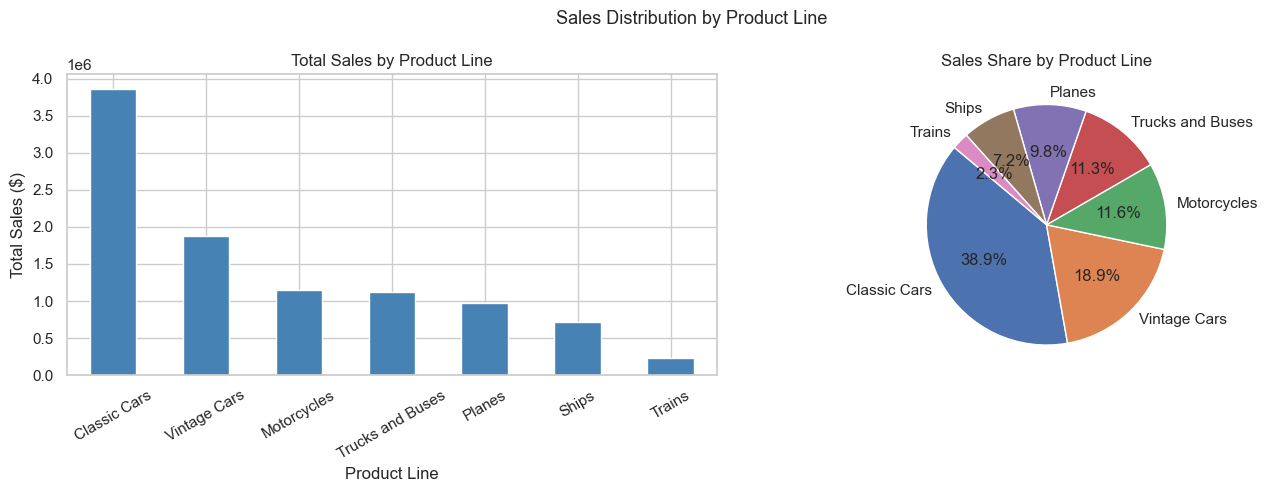

Sales by Product Line:
PRODUCTLINE
Classic Cars        3865484.790
Vintage Cars        1879004.410
Motorcycles         1154421.530
Trucks and Buses    1125623.055
Planes               970631.635
Ships                714437.130
Trains               225231.275
Name: SALES, dtype: float64


In [10]:
# ── Sales by Product Line ─────────────────────────────────────────────────────
sales_by_product = ddf.groupby('PRODUCTLINE')['SALES'].sum().compute().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sales_by_product.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Sales by Product Line')
axes[0].set_ylabel('Total Sales ($)')
axes[0].set_xlabel('Product Line')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(sales_by_product, labels=sales_by_product.index,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Sales Share by Product Line')

plt.suptitle('Sales Distribution by Product Line', fontsize=13)
plt.tight_layout()
plt.show()

print('Sales by Product Line:')
print(sales_by_product)

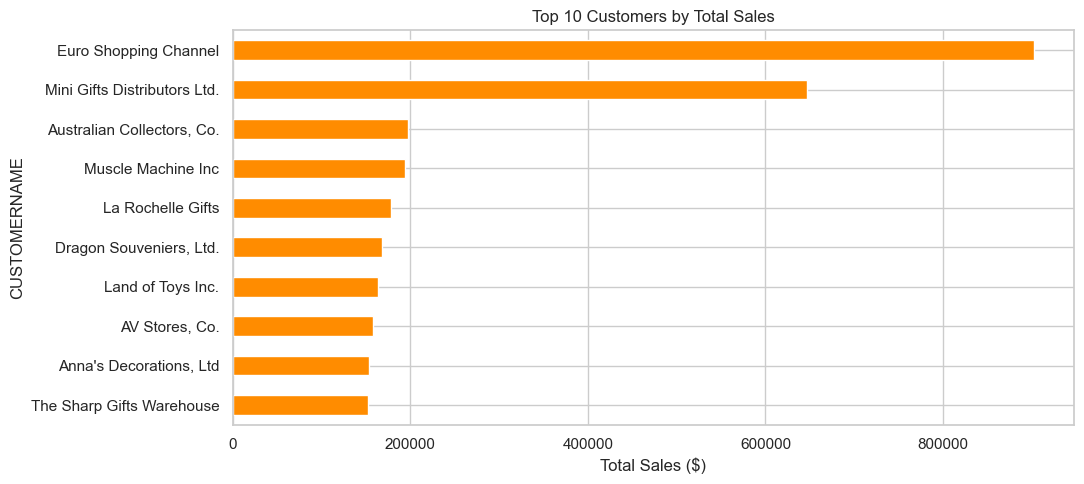

Top 10 Customers:
                   CUSTOMERNAME  Total Sales ($)
0         Euro Shopping Channel       902217.880
1  Mini Gifts Distributors Ltd.       647302.655
2    Australian Collectors, Co.       197886.230
3            Muscle Machine Inc       194248.690
4             La Rochelle Gifts       178050.155
5       Dragon Souveniers, Ltd.       168541.535
6             Land of Toys Inc.       164069.440
7                AV Stores, Co.       157807.810
8       Anna's Decorations, Ltd       153110.990
9     The Sharp Gifts Warehouse       152000.295


In [11]:
# ── Top 10 Customers by Total Sales ──────────────────────────────────────────
top_customers = (
    ddf.groupby('CUSTOMERNAME')['SALES']
    .sum()
    .compute()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
top_customers.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 10 Customers by Total Sales')
ax.set_xlabel('Total Sales ($)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 Customers:')
print(top_customers.reset_index().rename(columns={'SALES':'Total Sales ($)'}))

### 2.3 Sales Trends Over Time

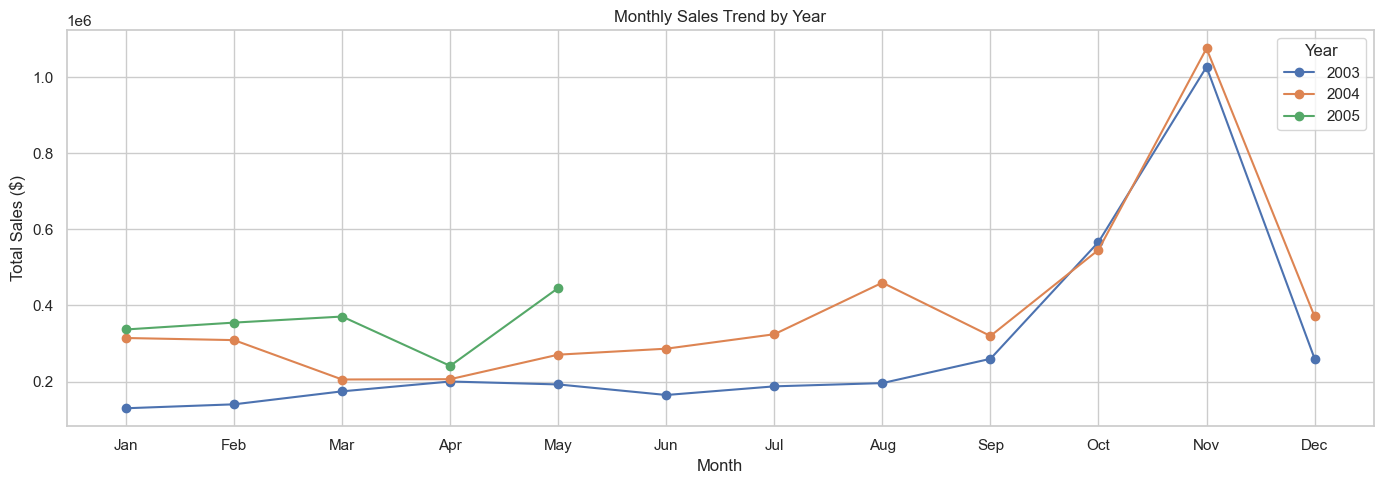

In [12]:
# ── Monthly Sales Trend ───────────────────────────────────────────────────────
monthly_sales = (
    ddf.groupby(['YEAR_ID','MONTH_ID'])['SALES']
    .sum()
    .compute()
    .reset_index()
    .sort_values(['YEAR_ID','MONTH_ID'])
)
monthly_sales['YearMonth'] = (monthly_sales['YEAR_ID'].astype(str) + '-'
                              + monthly_sales['MONTH_ID'].astype(str).str.zfill(2))

fig, ax = plt.subplots(figsize=(14, 5))
for year in sorted(monthly_sales['YEAR_ID'].unique()):
    subset = monthly_sales[monthly_sales['YEAR_ID'] == year]
    ax.plot(subset['MONTH_ID'], subset['SALES'], marker='o', label=str(year))

ax.set_title('Monthly Sales Trend by Year')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Year')
plt.tight_layout()
plt.show()

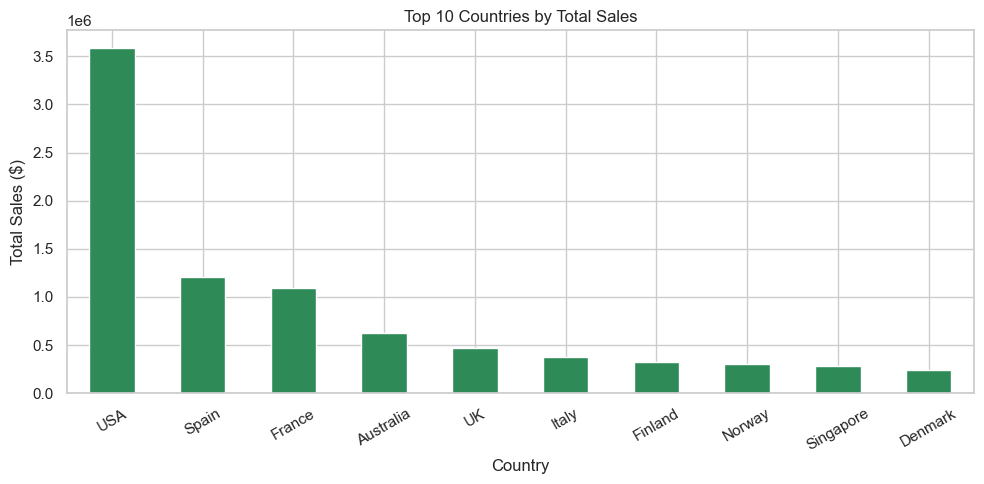

In [13]:
# ── Sales by Country ─────────────────────────────────────────────────────────
sales_by_country = (
    ddf.groupby('COUNTRY')['SALES']
    .sum()
    .compute()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
sales_by_country.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Top 10 Countries by Total Sales')
ax.set_ylabel('Total Sales ($)')
ax.set_xlabel('Country')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

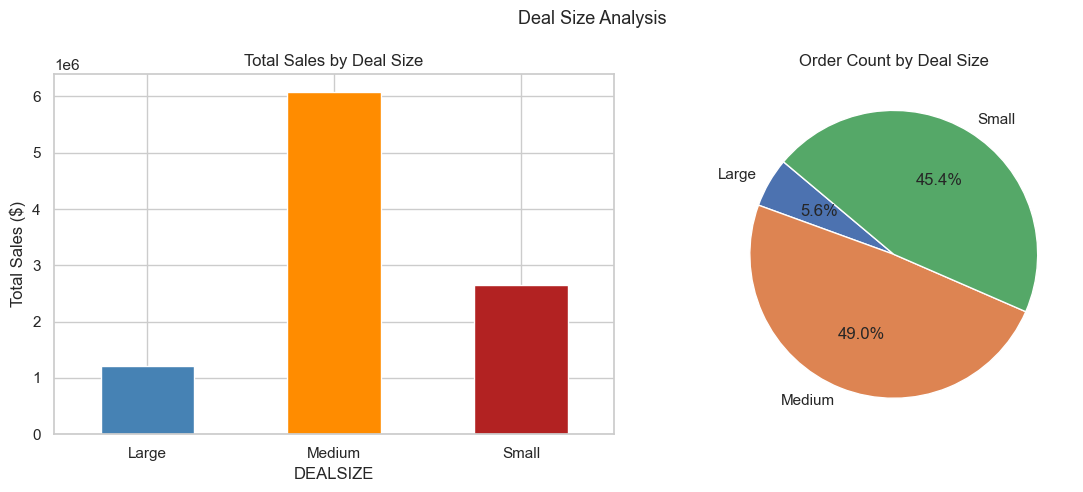

In [14]:
# ── Deal Size Distribution ────────────────────────────────────────────────────
deal_sales = ddf.groupby('DEALSIZE')['SALES'].sum().compute()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
deal_sales.plot(kind='bar', ax=axes[0], color=['steelblue','darkorange','firebrick'])
axes[0].set_title('Total Sales by Deal Size')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=0)

deal_count = ddf.groupby('DEALSIZE')['ORDERNUMBER'].count().compute()
deal_count.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Order Count by Deal Size')
axes[1].set_ylabel('')

plt.suptitle('Deal Size Analysis', fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Correlation heatmap

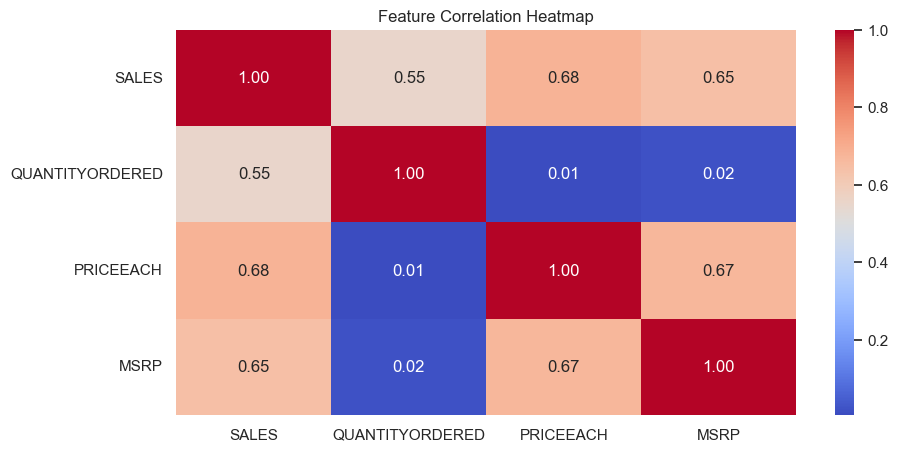

In [15]:
numeric_cols = ['SALES', 'QUANTITYORDERED', 'PRICEEACH', 'MSRP']
sns.heatmap(df_pd[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

---
## Task 3 — Feature Engineering

In [16]:
# ── Feature 1: Total spending per customer ────────────────────────────────────
customer_spending = (
    ddf.groupby('CUSTOMERNAME')['SALES']
    .sum()
    .compute()
    .reset_index()
    .rename(columns={'SALES': 'TOTAL_SPENDING'})
)
print('Total spending per customer (top 5):')
print(customer_spending.sort_values('TOTAL_SPENDING', ascending=False).head())

# ── Feature 2: Average sales per product line ─────────────────────────────────
avg_sales_product = (
    ddf.groupby('PRODUCTLINE')['SALES']
    .mean()
    .compute()
    .reset_index()
    .rename(columns={'SALES': 'AVG_SALES'})
)
print('\nAverage sales per product line:')
print(avg_sales_product.sort_values('AVG_SALES', ascending=False))

Total spending per customer (top 5):
                    CUSTOMERNAME  TOTAL_SPENDING
32         Euro Shopping Channel      902217.880
54  Mini Gifts Distributors Ltd.      647302.655
6     Australian Collectors, Co.      197886.230
57            Muscle Machine Inc      194248.690
43             La Rochelle Gifts      178050.155

Average sales per product line:
        PRODUCTLINE    AVG_SALES
0      Classic Cars  3997.398956
3  Trucks and Buses  3739.611478
1       Motorcycles  3487.678338
2            Planes  3171.998807
4      Vintage Cars  3095.559160
5             Ships  3053.150128
6            Trains  2925.081494


In [17]:
# ── Feature 3: Time-based features (Dask parallel computation) ───────────────
# Add quarter, day of week, is_weekend
ddf['QUARTER']     = ddf['ORDERDATE'].dt.quarter
ddf['DAY_OF_WEEK'] = ddf['ORDERDATE'].dt.dayofweek   # 0=Mon, 6=Sun
ddf['IS_WEEKEND']  = (ddf['DAY_OF_WEEK'] >= 5).astype(int)

# Feature 4: Revenue per unit
ddf['REVENUE_PER_UNIT'] = ddf['SALES'] / ddf['QUANTITYORDERED']

# Feature 5: Price discount ratio (MSRP vs actual price)
ddf['DISCOUNT_RATIO'] = ((ddf['MSRP'] - ddf['PRICEEACH']) / ddf['MSRP']).clip(0, 1)

print('New features added:')
print(ddf[['ORDERDATE','QUARTER','DAY_OF_WEEK','IS_WEEKEND',
           'REVENUE_PER_UNIT','DISCOUNT_RATIO']].head(5))

New features added:
   ORDERDATE  QUARTER  DAY_OF_WEEK  IS_WEEKEND  REVENUE_PER_UNIT  \
0 2003-02-24        1            0           0             95.70   
1 2003-05-07        2            2           0             81.35   
2 2003-07-01        3            1           0             94.74   
3 2003-08-25        3            0           0             83.26   
4 2003-10-10        4            4           0            106.23   

   DISCOUNT_RATIO  
0        0.000000  
1        0.143684  
2        0.002737  
3        0.123579  
4        0.000000  


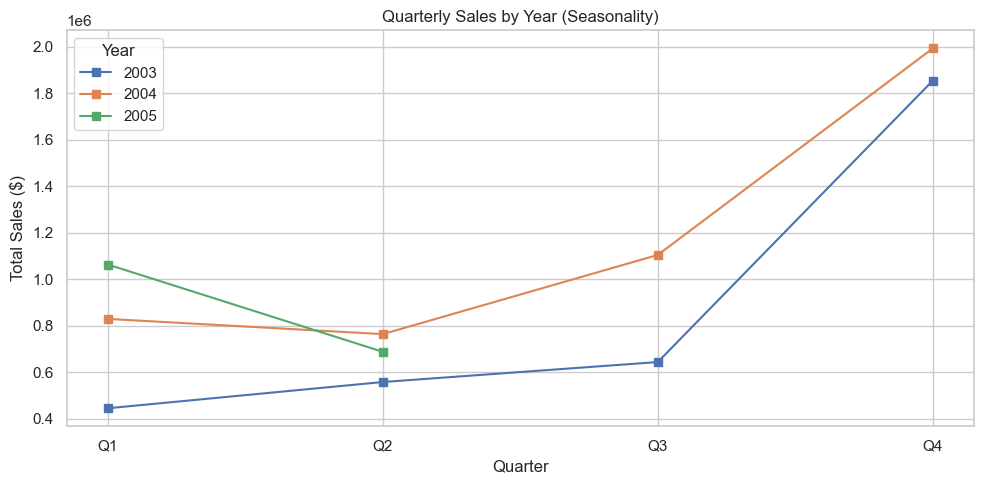

In [18]:
# ── Seasonality analysis using new QUARTER feature ───────────────────────────
quarterly_sales = (
    ddf.groupby(['YEAR_ID','QUARTER'])['SALES']
    .sum()
    .compute()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for year in sorted(quarterly_sales['YEAR_ID'].unique()):
    subset = quarterly_sales[quarterly_sales['YEAR_ID'] == year]
    ax.plot(subset['QUARTER'], subset['SALES'], marker='s', label=str(year))

ax.set_title('Quarterly Sales by Year (Seasonality)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales ($)')
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax.legend(title='Year')
plt.tight_layout()
plt.show()

---
## Task 4 — Advanced Analytics

### 4.1 Customer Segmentation with K-Means Clustering

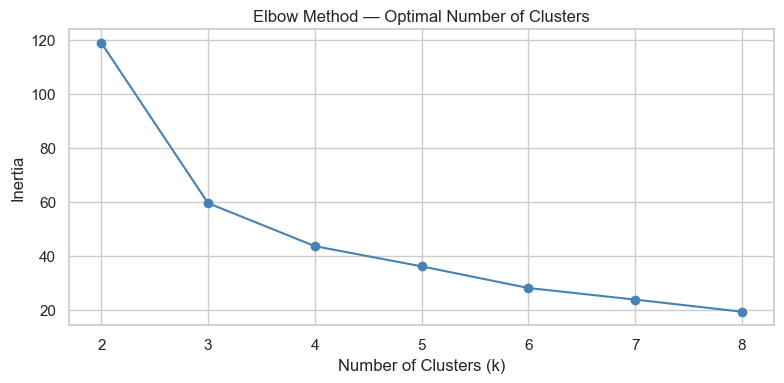

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Build RFM-style features per customer
df_pd = ddf.compute()

rfm = df_pd.groupby('CUSTOMERNAME').agg(
    TOTAL_SALES   = ('SALES', 'sum'),
    ORDER_COUNT   = ('ORDERNUMBER', 'nunique'),
    AVG_ORDER_VAL = ('SALES', 'mean')
).reset_index()

# Scale features
scaler  = StandardScaler()
X_rfm   = scaler.fit_transform(rfm[['TOTAL_SALES','ORDER_COUNT','AVG_ORDER_VAL']])

# Elbow method to find optimal k
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_rfm)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, marker='o', color='steelblue')
ax.set_title('Elbow Method — Optimal Number of Clusters')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.show()

RFM stats before outlier removal:
       TOTAL_SALES  ORDER_COUNT  AVG_ORDER_VAL
count        92.00        92.00          92.00
mean     107987.32         3.34        3519.74
std      108991.58         2.92         351.76
min        9129.35         1.00        2499.57
25%       69622.36         2.00        3307.68
50%       86522.61         3.00        3508.98
75%      118088.60         3.00        3750.68
max      902217.88        26.00        4620.54

IQR upper bound for ORDER_COUNT: 4.5
Extreme customers removed from clustering: 6
                    CUSTOMERNAME  TOTAL_SALES  ORDER_COUNT  AVG_ORDER_VAL
6     Australian Collectors, Co.   197886.230            5    3597.931455
27      Danish Wholesale Imports   141402.215            5    3927.839306
31       Dragon Souveniers, Ltd.   168541.535            5    3919.570581
33         Euro Shopping Channel   902217.880           26    3483.466718
55  Mini Gifts Distributors Ltd.   647302.655           17    3596.125861
66            Re

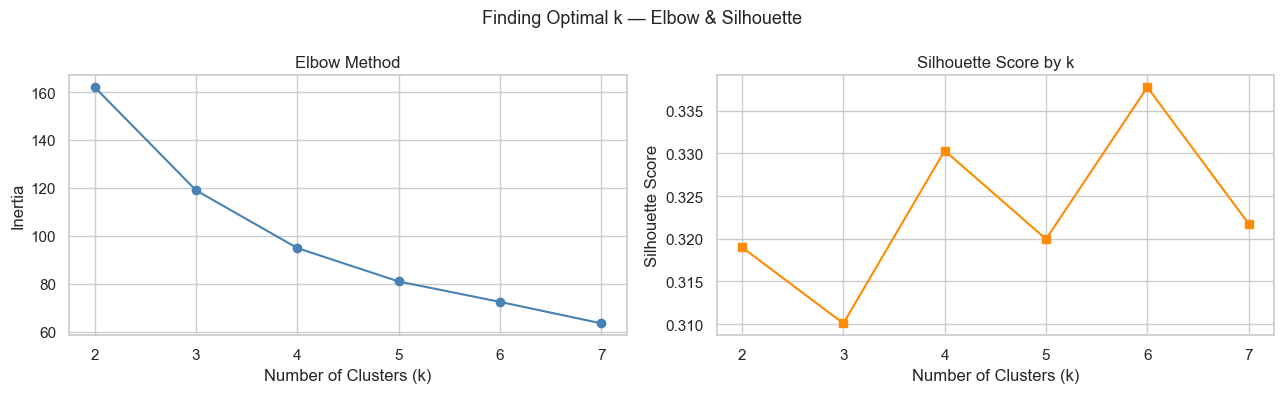


Silhouette Scores:
  k=2: 0.3190
  k=3: 0.3101
  k=4: 0.3303
  k=5: 0.3200
  k=6: 0.3377
  k=7: 0.3218

Best k by silhouette score: 6
Silhouette Score (k=6): 0.3377

Cluster Profiles (main clusters):
         TOTAL_SALES  ORDER_COUNT  AVG_ORDER_VAL
CLUSTER                                         
0           94778.69         2.00        3901.10
1           74967.00         3.00        3262.96
2          145511.99         3.71        3480.65
3           46603.60         1.80        2884.82
4           60140.86         2.00        3444.99
5           92542.62         3.20        3863.93

Cluster Labels:
  Cluster 0 — Mid Value
  Cluster 1 — Mid Value
  Cluster 2 — High Value
  Cluster 3 — Low Value
  Cluster 4 — Mid Value
  Cluster 5 — Mid Value
  Cluster -1 — VIP / Extreme customers (excluded from K-Means)


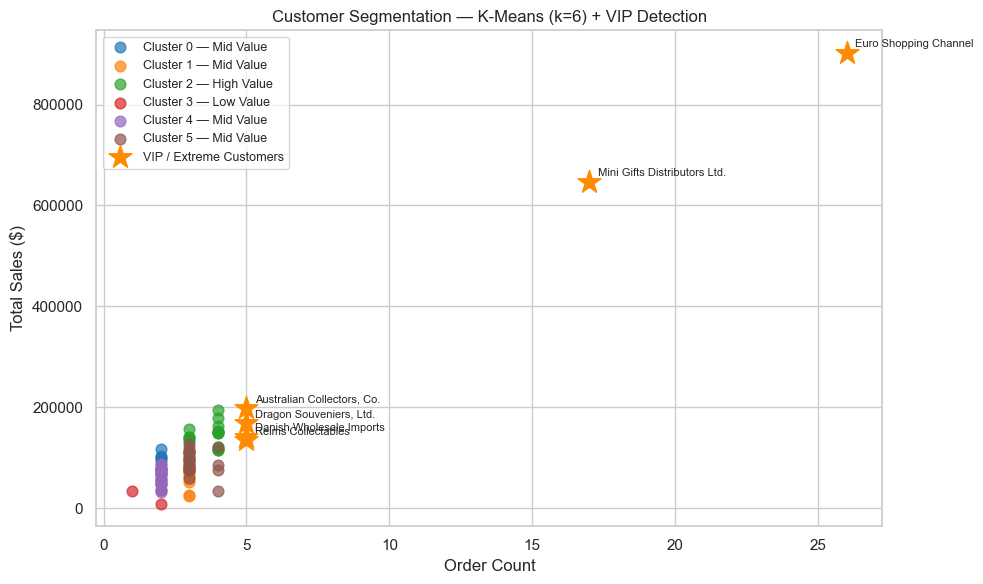

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# ── Step 1: Check outliers in RFM before clustering ───────────────────────────
print('RFM stats before outlier removal:')
print(rfm[['TOTAL_SALES','ORDER_COUNT','AVG_ORDER_VAL']].describe().round(2))

# ── Step 2: Remove extreme outliers using IQR on ORDER_COUNT ──────────────────
Q1 = rfm['ORDER_COUNT'].quantile(0.25)
Q3 = rfm['ORDER_COUNT'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Separate outlier customers (keep them labeled separately)
rfm_outliers = rfm[rfm['ORDER_COUNT'] > upper_bound].copy()
rfm_clean    = rfm[rfm['ORDER_COUNT'] <= upper_bound].copy()

print(f'\nIQR upper bound for ORDER_COUNT: {upper_bound:.1f}')
print(f'Extreme customers removed from clustering: {len(rfm_outliers)}')
print(rfm_outliers[['CUSTOMERNAME','TOTAL_SALES','ORDER_COUNT','AVG_ORDER_VAL']])
print(f'Customers used for clustering: {len(rfm_clean)}')

# ── Step 3: Scale features ────────────────────────────────────────────────────
scaler  = StandardScaler()
X_clean = scaler.fit_transform(
    rfm_clean[['TOTAL_SALES','ORDER_COUNT','AVG_ORDER_VAL']]
)

# ── Step 4: Elbow + Silhouette to find optimal k ──────────────────────────────
inertias   = []
sil_scores = []
K_range    = range(2, 8)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_clean)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clean, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='s', color='darkorange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Finding Optimal k — Elbow & Silhouette', fontsize=13)
plt.tight_layout()
plt.show()

# Print scores to help pick k
print('\nSilhouette Scores:')
for k, s in zip(K_range, sil_scores):
    print(f'  k={k}: {s:.4f}')

# ── Step 5: Apply K-Means with best k ────────────────────────────────────────
# Pick k with highest silhouette score
k_optimal = list(K_range)[np.argmax(sil_scores)]
print(f'\nBest k by silhouette score: {k_optimal}')

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm_clean['CLUSTER'] = kmeans.fit_predict(X_clean)

# Label outlier customers as separate group
rfm_outliers['CLUSTER'] = -1  # -1 = VIP/Outlier group

# Combine back
rfm_final = pd.concat([rfm_clean, rfm_outliers], ignore_index=True)

# ── Step 6: Cluster profiles ──────────────────────────────────────────────────
sil_final = silhouette_score(X_clean, rfm_clean['CLUSTER'])
print(f'Silhouette Score (k={k_optimal}): {sil_final:.4f}')

print('\nCluster Profiles (main clusters):')
profile = rfm_clean.groupby('CLUSTER')[
    ['TOTAL_SALES','ORDER_COUNT','AVG_ORDER_VAL']
].mean().round(2)
print(profile)

# Add descriptive labels based on profile
cluster_labels = {}
for c in range(k_optimal):
    row = profile.loc[c]
    if row['TOTAL_SALES'] == profile['TOTAL_SALES'].max():
        cluster_labels[c] = f'Cluster {c} — High Value'
    elif row['TOTAL_SALES'] == profile['TOTAL_SALES'].min():
        cluster_labels[c] = f'Cluster {c} — Low Value'
    else:
        cluster_labels[c] = f'Cluster {c} — Mid Value'

print('\nCluster Labels:')
for c, label in cluster_labels.items():
    print(f'  {label}')
print('  Cluster -1 — VIP / Extreme customers (excluded from K-Means)')

# ── Step 7: Final scatter plot ────────────────────────────────────────────────
# Generate enough colors dynamically based on k_optimal
colors = [cm.tab10(i) for i in range(k_optimal)]  # supports up to 10 clusters

fig, ax = plt.subplots(figsize=(10, 6))

# Plot main clusters
for c in range(k_optimal):
    sub = rfm_clean[rfm_clean['CLUSTER'] == c]
    ax.scatter(sub['ORDER_COUNT'], sub['TOTAL_SALES'],
               label=cluster_labels[c],
               color=colors[c], alpha=0.7, s=60)

# Plot VIP outliers separately
ax.scatter(rfm_outliers['ORDER_COUNT'], rfm_outliers['TOTAL_SALES'],
           label='VIP / Extreme Customers',
           color='darkorange', marker='*', s=300, zorder=5)

# Annotate VIP customers
for _, row in rfm_outliers.iterrows():
    ax.annotate(row['CUSTOMERNAME'],
                (row['ORDER_COUNT'], row['TOTAL_SALES']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('Order Count')
ax.set_ylabel('Total Sales ($)')
ax.set_title(f'Customer Segmentation — K-Means (k={k_optimal}) + VIP Detection')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 Sales Forecasting with Random Forest + Gradient Boosting

Train size : 2258 | Test size : 565
Train period: YEAR 2003 — 2004
Test  period: YEAR 2004 — 2005

Random Forest — Predict QUANTITYORDERED:
  MAE  = 7.2927
  RMSE = 9.8235
  R²   = 0.3342

Gradient Boosting — Predict QUANTITYORDERED:
  MAE  = 7.1593
  RMSE = 9.4251
  R²   = 0.3871

Model Comparison:
            Model      MAE     RMSE       R²
    Random Forest 7.292704 9.823509 0.334159
Gradient Boosting 7.159320 9.425114 0.387070


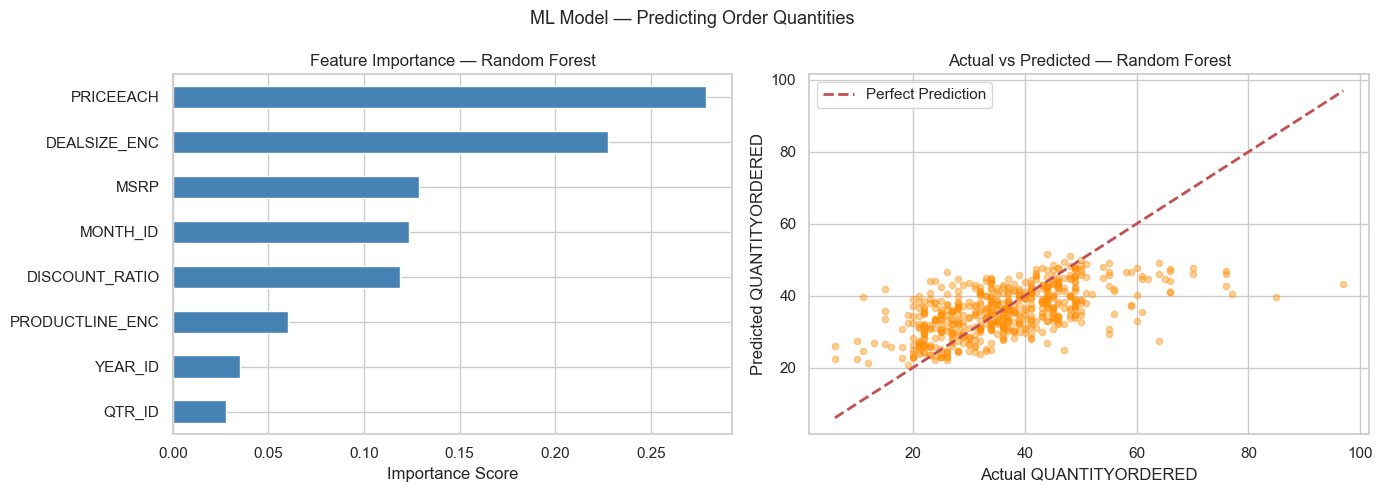

In [ ]:

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ── Build feature matrix for predicting QUANTITYORDERED ──────────────────────
# Features: PRICEEACH, MSRP, PRODUCTLINE, DEALSIZE, MONTH_ID, QTR_ID, YEAR_ID
# Target  : QUANTITYORDERED

df_ml = df_pd[['PRICEEACH', 'MSRP', 'PRODUCTLINE', 'DEALSIZE',
               'MONTH_ID', 'QTR_ID', 'YEAR_ID', 'DISCOUNT_RATIO',
               'QUANTITYORDERED']].copy()

# ── Sort by time to prevent data leakage ─────────────────────────────────────
# CRITICAL: Must sort chronologically before splitting.
# Using random shuffle on time series data causes leakage —
# future data leaks into the training set, inflating model performance.
df_ml = df_ml.sort_values(['YEAR_ID', 'MONTH_ID']).reset_index(drop=True)

# Encode categorical columns
le_product  = LabelEncoder()
le_dealsize = LabelEncoder()
df_ml['PRODUCTLINE_ENC'] = le_product.fit_transform(df_ml['PRODUCTLINE'])
df_ml['DEALSIZE_ENC']    = le_dealsize.fit_transform(df_ml['DEALSIZE'])

feature_cols = ['PRICEEACH', 'MSRP', 'DISCOUNT_RATIO',
                'MONTH_ID', 'QTR_ID', 'YEAR_ID',
                'PRODUCTLINE_ENC', 'DEALSIZE_ENC']

X = df_ml[feature_cols]
y = df_ml['QUANTITYORDERED']

# ── Chronological split (no shuffle) ─────────────────────────────────────────
split_idx = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train size : {len(X_train)} | Test size : {len(X_test)}')
print(f'Train period: YEAR {df_ml.iloc[:split_idx]["YEAR_ID"].min()} — {df_ml.iloc[:split_idx]["YEAR_ID"].max()}')
print(f'Test  period: YEAR {df_ml.iloc[split_idx:]["YEAR_ID"].min()} — {df_ml.iloc[split_idx:]["YEAR_ID"].max()}')

# ── Model 1: Random Forest ────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'\nRandom Forest — Predict QUANTITYORDERED:')
print(f'  MAE  = {mae_rf:.4f}')
print(f'  RMSE = {rmse_rf:.4f}')
print(f'  R²   = {r2_rf:.4f}')

# ── Model 2: Gradient Boosting ────────────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print(f'\nGradient Boosting — Predict QUANTITYORDERED:')
print(f'  MAE  = {mae_gb:.4f}')
print(f'  RMSE = {rmse_gb:.4f}')
print(f'  R²   = {r2_gb:.4f}')

# ── Model Comparison Table ────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model':  ['Random Forest', 'Gradient Boosting'],
    'MAE':    [mae_rf,  mae_gb],
    'RMSE':   [rmse_rf, rmse_gb],
    'R²':     [r2_rf,   r2_gb]
})
print('\nModel Comparison:')
print(comparison.to_string(index=False))

# ── Feature Importance (Random Forest) ───────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Random Forest')
axes[0].set_xlabel('Importance Score')

# Actual vs Predicted
axes[1].scatter(y_test, y_pred_rf, alpha=0.4, color='darkorange', s=20)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted — Random Forest')
axes[1].set_xlabel('Actual QUANTITYORDERED')
axes[1].set_ylabel('Predicted QUANTITYORDERED')
axes[1].legend()

plt.suptitle('ML Model — Predicting Order Quantities', fontsize=13)
plt.tight_layout()
plt.show()

### 4.3 Association Rule Mining — Products Bought Together

In [22]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Build basket: each order → list of product lines
basket = (
    df_pd.groupby('ORDERNUMBER')['PRODUCTLINE']
    .apply(list)
    .reset_index()
)

te = TransactionEncoder()
te_array = te.fit_transform(basket['PRODUCTLINE'])
basket_df = pd.DataFrame(te_array, columns=te.columns_)

# Frequent itemsets
frequent_itemsets = apriori(basket_df, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print(f'Frequent itemsets found: {len(frequent_itemsets)}')
print(f'Association rules found: {len(rules)}')
print('\nTop 10 rules by lift:')
print(rules[['antecedents','consequents','support','confidence','lift']]
      .head(10).to_string(index=False))

Frequent itemsets found: 31
Association rules found: 74

Top 10 rules by lift:
                                    antecedents                                     consequents  support  confidence     lift
               frozenset({Ships, Classic Cars})               frozenset({Vintage Cars, Trains}) 0.058632    0.500000 5.903846
              frozenset({Vintage Cars, Trains})                frozenset({Ships, Classic Cars}) 0.058632    0.692308 5.903846
         frozenset({Vintage Cars, Motorcycles})                             frozenset({Planes}) 0.058632    0.857143 4.460048
                            frozenset({Planes})          frozenset({Vintage Cars, Motorcycles}) 0.058632    0.305085 4.460048
                             frozenset({Ships})               frozenset({Vintage Cars, Trains}) 0.074919    0.353846 4.178107
              frozenset({Vintage Cars, Trains})                              frozenset({Ships}) 0.074919    0.884615 4.178107
frozenset({Vintage Cars, Trains, Classi

---
## Task 5 — Performance Optimization with Dask

In [23]:
import time

# ── Repartition for optimal parallel processing ───────────────────────────────
print(f'Original partitions: {ddf.npartitions}')

# Repartition to 4 partitions (suitable for a 4-core machine)
ddf_optimized = ddf.repartition(npartitions=4)
print(f'After repartition: {ddf_optimized.npartitions}')

Original partitions: 4
After repartition: 4


In [24]:
dtype_spec = {
    'ADDRESSLINE2': 'str',
    'STATE':        'str',
    'POSTALCODE':   'str',
    'TERRITORY':    'str'
}

df_small   = pd.read_csv('data/sales_data_sample.csv', encoding='latin1')
df_large   = pd.concat([df_small] * 500, ignore_index=True)
LARGE_PATH = 'data/sales_data_large.csv'
df_large.to_csv(LARGE_PATH, index=False)

print(f'Large dataset created: {len(df_large):,} rows × {len(df_large.columns)} columns')
print(f'Saved to: {LARGE_PATH}')

Large dataset created: 1,411,500 rows × 25 columns
Saved to: data/sales_data_large.csv



── 5.1 Partition Size Tuning ──
Default partitions : 4
Estimated size     : 470.05 MB
  npartitions= 2 → 4.3695s
  npartitions= 4 → 5.0623s
  npartitions= 8 → 4.5977s
  npartitions=16 → 4.2215s

Best partition size: 16 (fastest: 4.2215s)
ddf_optimized set to 16 partitions


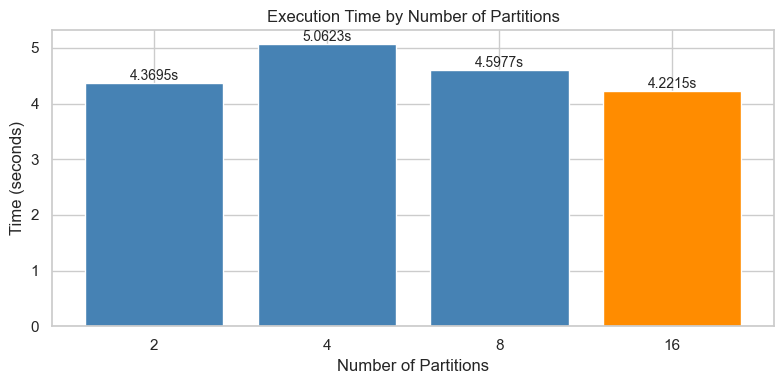

In [25]:
# ════════════════════════════════════════════════════════════
# 5.1 — Partition Size Tuning
# ════════════════════════════════════════════════════════════
print('\n── 5.1 Partition Size Tuning ──')

# Load large dataset
ddf_base = dd.read_csv(LARGE_PATH, dtype=dtype_spec)
print(f'Default partitions : {ddf_base.npartitions}')
print(f'Estimated size     : {ddf_base.memory_usage(deep=True).sum().compute() / 1e6:.2f} MB')

# Test different partition sizes and measure performance
partition_tests = [2, 4, 8, 16]
partition_times = []

for n in partition_tests:
    ddf_p = ddf_base.repartition(npartitions=n)
    t0    = time.time()
    _     = ddf_p.groupby('PRODUCTLINE')['SALES'].sum().compute()
    elapsed = time.time() - t0
    partition_times.append(elapsed)
    print(f'  npartitions={n:>2} → {elapsed:.4f}s')

# Find best partition size
best_n = partition_tests[partition_times.index(min(partition_times))]
print(f'\nBest partition size: {best_n} (fastest: {min(partition_times):.4f}s)')

# Apply optimal partition
ddf_optimized = ddf_base.repartition(npartitions=best_n)
print(f'ddf_optimized set to {best_n} partitions')

# Plot partition tuning results
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([str(n) for n in partition_tests], partition_times,
              color=['darkorange' if n == best_n else 'steelblue'
                     for n in partition_tests])
ax.set_title('Execution Time by Number of Partitions')
ax.set_xlabel('Number of Partitions')
ax.set_ylabel('Time (seconds)')
for bar, val in zip(bars, partition_times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


── 5.2 Lazy Evaluation & Memory Usage ──
Lazy pipeline built — nothing computed yet
Type: <class 'dask.dataframe.dask_expr._collection.Series'>
(graphviz not available — skipping task graph)

Full pipeline computed in 4.9973s
PRODUCTLINE       YEAR_ID
Classic Cars      2004       114.534049
Motorcycles       2004        98.765366
Planes            2004        90.395600
Ships             2003        86.476986
                  2005        92.826087
Trains            2003        72.698929
                  2005        84.593636
Trucks and Buses  2004       103.930145
Vintage Cars      2003        87.971852
                  2005        95.026667
Name: REVENUE_PER_UNIT, dtype: float64

Memory Usage Comparison:
  Pandas (eager load) : +246.8 MB loaded into RAM immediately
  Dask   (lazy load)  : +3.2 MB (only metadata, data loaded on demand)
  Memory saved        : 243.6 MB


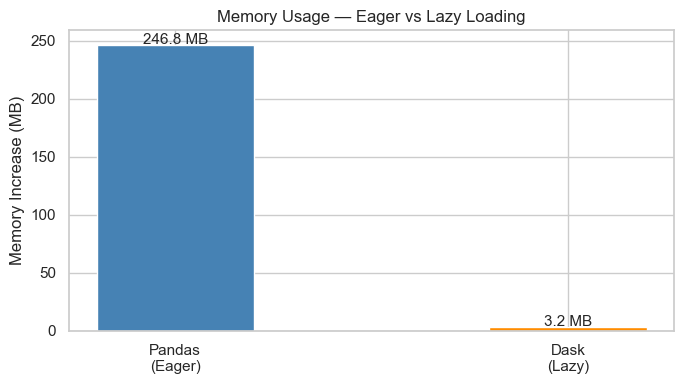

In [26]:
# ════════════════════════════════════════════════════════════
# 5.2 — Lazy Evaluation & Efficient Memory Usage
# ════════════════════════════════════════════════════════════
print('\n── 5.2 Lazy Evaluation & Memory Usage ──')

# ── Lazy evaluation: chain multiple operations WITHOUT computing ──────────────
lazy_pipeline = (
    ddf_optimized
    .assign(REVENUE_PER_UNIT = ddf_optimized['SALES'] / ddf_optimized['QUANTITYORDERED'])
    .query("STATUS == 'Shipped'")
    .groupby(['PRODUCTLINE', 'YEAR_ID'])['REVENUE_PER_UNIT']
    .mean()
)

print('Lazy pipeline built — nothing computed yet')
print(f'Type: {type(lazy_pipeline)}')

# Visualize the task graph
try:
    lazy_pipeline.visualize(filename='task_graph.png', rankdir='LR')
    print('Task graph saved → task_graph.png')
    from IPython.display import Image
    display(Image('task_graph.png'))
except Exception:
    print('(graphviz not available — skipping task graph)')

# Trigger computation once
t0     = time.time()
result = lazy_pipeline.compute()
elapsed = time.time() - t0
print(f'\nFull pipeline computed in {elapsed:.4f}s')
print(result.head(10))

# ── Memory usage: compare eager vs lazy loading ───────────────────────────────
import psutil, os

process = psutil.Process(os.getpid())

# Eager (Pandas): loads everything into RAM immediately
mem_before = process.memory_info().rss / 1e6
df_eager   = pd.read_csv(LARGE_PATH)
mem_after  = process.memory_info().rss / 1e6
pandas_mem = mem_after - mem_before
print(f'\nMemory Usage Comparison:')
print(f'  Pandas (eager load) : +{pandas_mem:.1f} MB loaded into RAM immediately')

# Lazy (Dask): only metadata loaded
mem_before  = process.memory_info().rss / 1e6
ddf_lazy    = dd.read_csv(LARGE_PATH, dtype=dtype_spec)
mem_after   = process.memory_info().rss / 1e6
dask_mem    = mem_after - mem_before
print(f'  Dask   (lazy load)  : +{dask_mem:.1f} MB (only metadata, data loaded on demand)')
print(f'  Memory saved        : {pandas_mem - dask_mem:.1f} MB')

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Pandas\n(Eager)', 'Dask\n(Lazy)'],
       [pandas_mem, dask_mem],
       color=['steelblue', 'darkorange'], width=0.4)
ax.set_title('Memory Usage — Eager vs Lazy Loading')
ax.set_ylabel('Memory Increase (MB)')
for i, val in enumerate([pandas_mem, dask_mem]):
    ax.text(i, val + 0.5, f'{val:.1f} MB', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


── 5.3 Distributed Scheduler ──
Available CPU cores: 16

Synchronous scheduler   : 7.3570s
Threaded scheduler      : 5.2160s

Distributed Client: <Client: 'tcp://127.0.0.1:63055' processes=4 threads=8, memory=7.45 GiB>
Dashboard         : http://127.0.0.1:8787/status


2026-05-23 19:51:04,685 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1c2058167b13640ed6e1480cc3d14709 initialized by task ('shuffle-transfer-1c2058167b13640ed6e1480cc3d14709', 3) executed on worker tcp://127.0.0.1:63074
2026-05-23 19:51:05,432 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1c2058167b13640ed6e1480cc3d14709 deactivated due to stimulus 'task-finished-1779540665.4311192'


Distributed scheduler   : 4.7887s
Client closed.


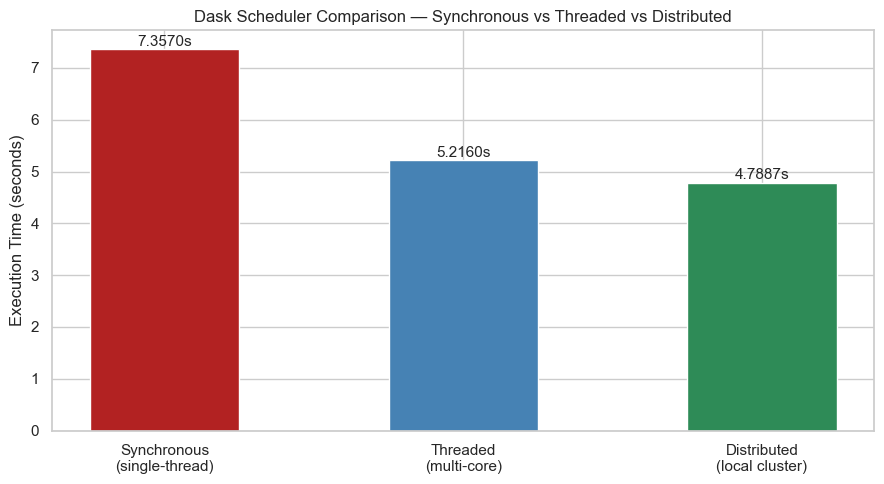


Task 5 — Optimization Summary:
            Technique                                          What it does                                Result
     Partition Tuning         Finds optimal npartitions for fastest compute         Best: 16 partitions (4.2215s)
      Lazy Evaluation Builds pipeline without loading data until .compute()          Pipeline computed in 4.9973s
    Memory Efficiency Dask loads only metadata vs Pandas loads all into RAM               Saved ~244 MB vs Pandas
Distributed Scheduler            Spreads work across multiple cores/workers Distributed: 4.7887s vs Sync: 7.3570s


In [27]:
# ════════════════════════════════════════════════════════════
# 5.3 — Distributed Scheduler (Multi-core)
# ════════════════════════════════════════════════════════════
print('\n── 5.3 Distributed Scheduler ──')

import os
n_cores = os.cpu_count()
print(f'Available CPU cores: {n_cores}')

# ── Compare: synchronous vs distributed scheduler ────────────────────────────
# Operation to benchmark
def run_aggregation(ddf):
    return (
        ddf.groupby(['PRODUCTLINE', 'YEAR_ID', 'DEALSIZE'])['SALES']
        .agg(['sum', 'mean', 'count'])
        .compute()
    )

# Synchronous scheduler (single-threaded)
ddf_bench = dd.read_csv(LARGE_PATH, dtype=dtype_spec).repartition(npartitions=best_n)

t0 = time.time()
with dask.config.set(scheduler='synchronous'):
    _ = run_aggregation(ddf_bench)
sync_time = time.time() - t0
print(f'\nSynchronous scheduler   : {sync_time:.4f}s')

# Threaded scheduler (default, uses all cores)
t0 = time.time()
with dask.config.set(scheduler='threads'):
    _ = run_aggregation(ddf_bench)
threaded_time = time.time() - t0
print(f'Threaded scheduler      : {threaded_time:.4f}s')

# Distributed scheduler (local cluster)
client = Client(
    n_workers         = min(4, n_cores),
    threads_per_worker = 2,
    memory_limit      = '2GB'
)
print(f'\nDistributed Client: {client}')
print(f'Dashboard         : {client.dashboard_link}')

t0 = time.time()
_ = run_aggregation(ddf_bench)
dist_time = time.time() - t0
print(f'Distributed scheduler   : {dist_time:.4f}s')

client.close()
print('Client closed.')

# ── Scheduler comparison chart ────────────────────────────────────────────────
schedulers = ['Synchronous\n(single-thread)', 'Threaded\n(multi-core)', 'Distributed\n(local cluster)']
times      = [sync_time, threaded_time, dist_time]
colors_bar = ['firebrick', 'steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(schedulers, times, color=colors_bar, width=0.5)
ax.set_title('Dask Scheduler Comparison — Synchronous vs Threaded vs Distributed')
ax.set_ylabel('Execution Time (seconds)')
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# ── Final summary ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Technique':      ['Partition Tuning',
                       'Lazy Evaluation',
                       'Memory Efficiency',
                       'Distributed Scheduler'],
    'What it does':   ['Finds optimal npartitions for fastest compute',
                       'Builds pipeline without loading data until .compute()',
                       'Dask loads only metadata vs Pandas loads all into RAM',
                       'Spreads work across multiple cores/workers'],
    'Result':         [f'Best: {best_n} partitions ({min(partition_times):.4f}s)',
                       f'Pipeline computed in {elapsed:.4f}s',
                       f'Saved ~{pandas_mem - dask_mem:.0f} MB vs Pandas',
                       f'Distributed: {dist_time:.4f}s vs Sync: {sync_time:.4f}s']
})
print('\nTask 5 — Optimization Summary:')
print(summary.to_string(index=False))

---
## Task 6 — Reporting and Visualization Dashboard

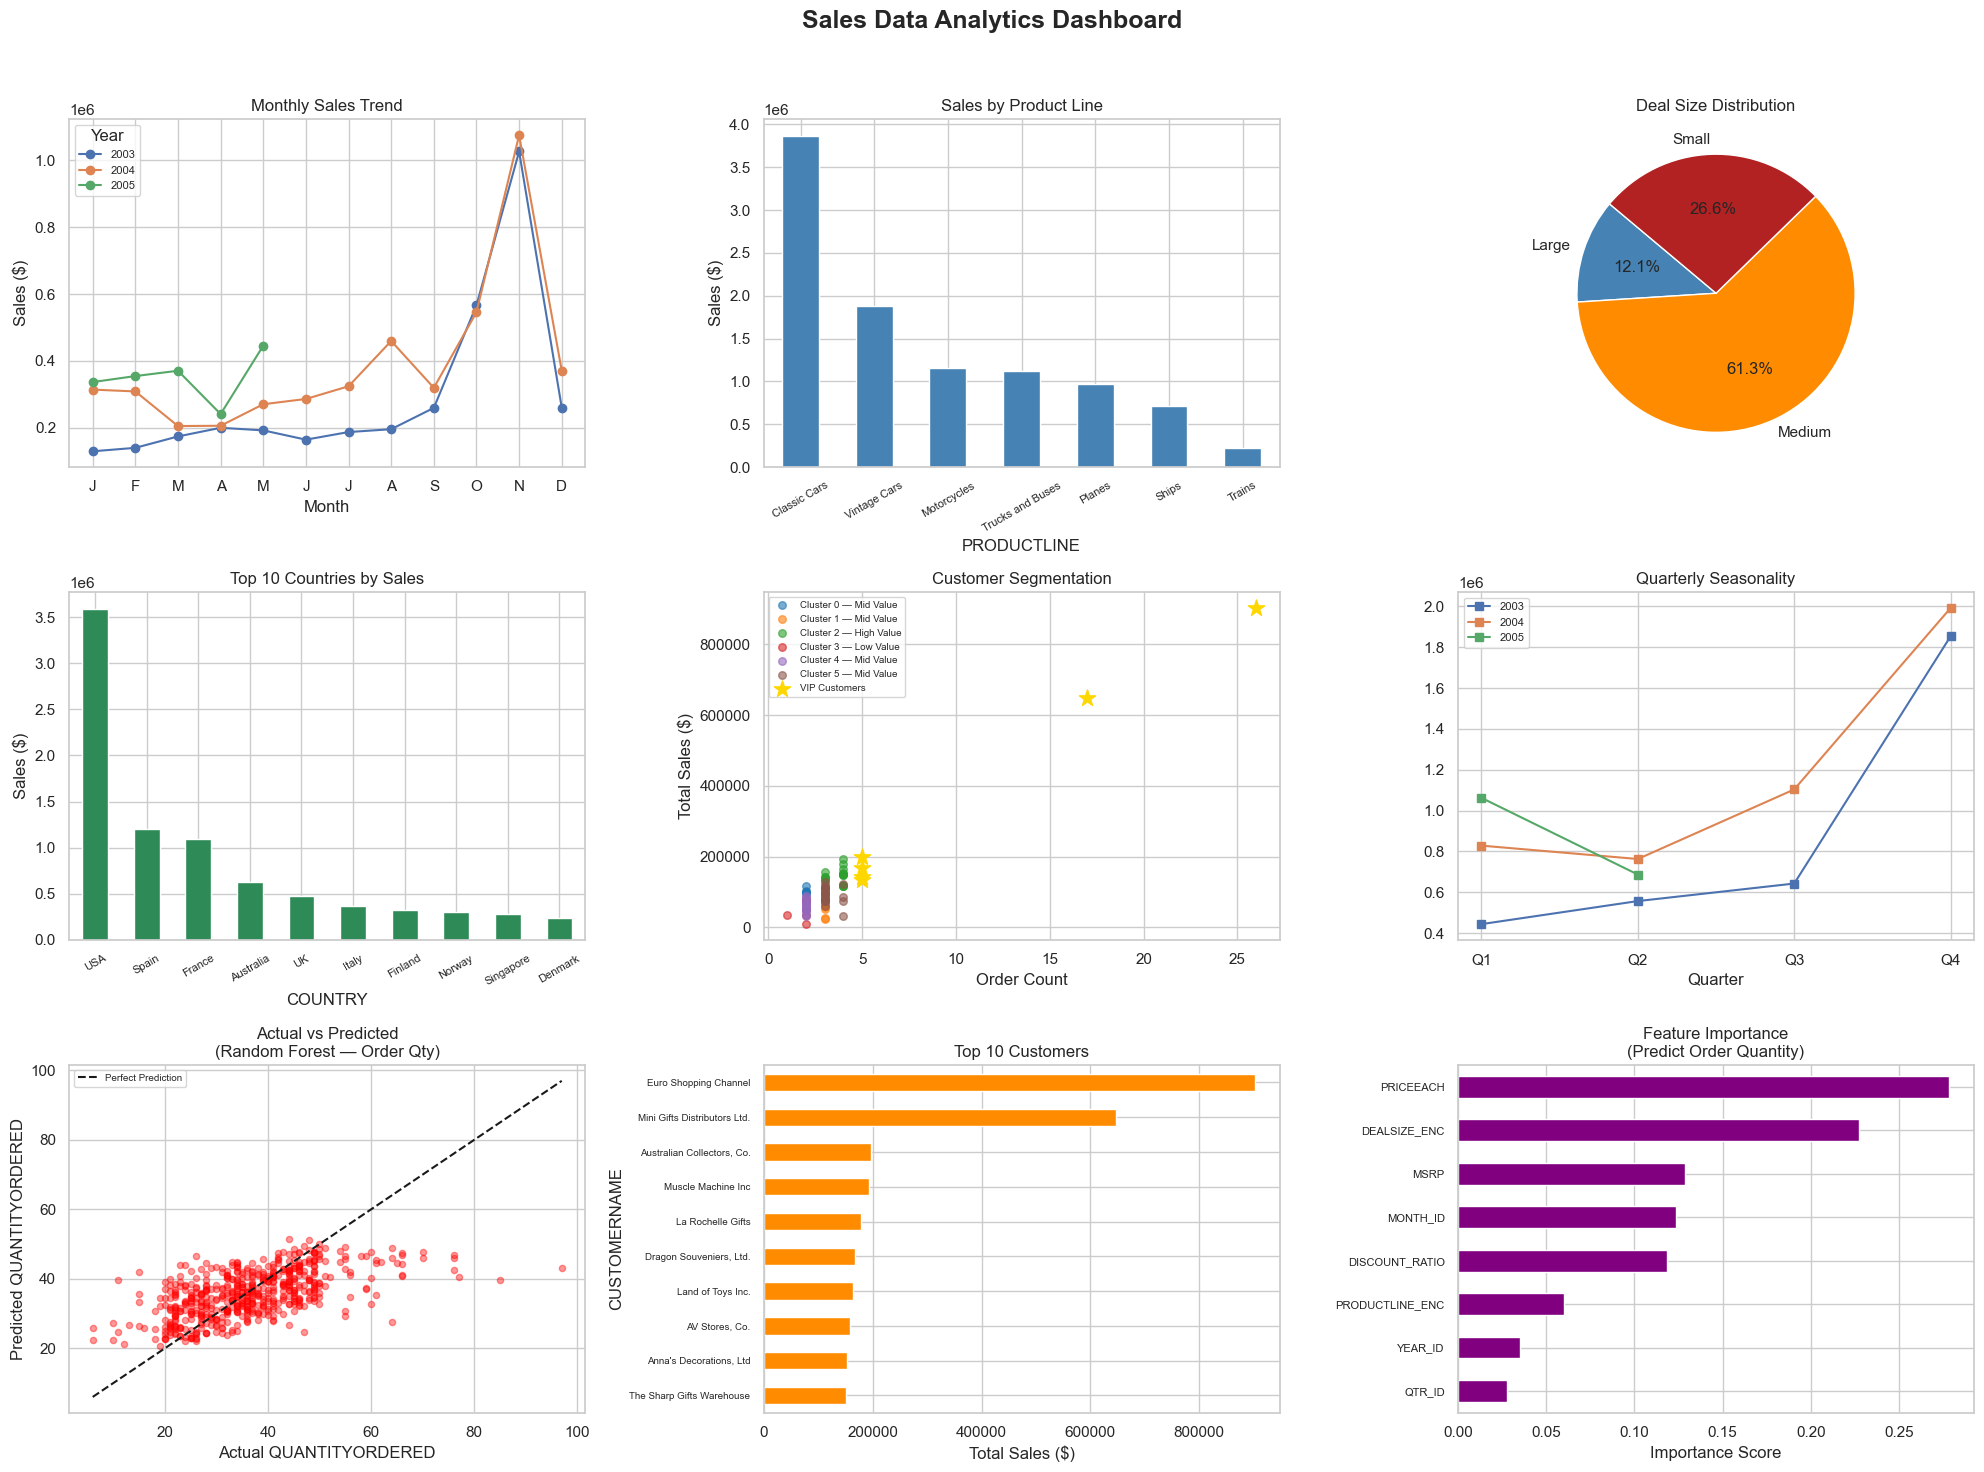

Dashboard saved → output/sales_dashboard.png


In [28]:
import matplotlib.cm as cm

fig = plt.figure(figsize=(20, 15))
fig.suptitle('Sales Data Analytics Dashboard', fontsize=18,
             fontweight='bold', y=0.98)

# ── Plot 1: Monthly Sales Trend ───────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
for year in sorted(monthly_sales['YEAR_ID'].unique()):
    s = monthly_sales[monthly_sales['YEAR_ID'] == year]
    ax1.plot(s['MONTH_ID'], s['SALES'], marker='o', label=str(year))
ax1.set_title('Monthly Sales Trend')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sales ($)')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax1.legend(fontsize=8, title='Year')

# ── Plot 2: Sales by Product Line ─────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
sales_by_product.plot(kind='bar', ax=ax2, color='steelblue')
ax2.set_title('Sales by Product Line')
ax2.set_ylabel('Sales ($)')
ax2.tick_params(axis='x', rotation=30, labelsize=8)

# ── Plot 3: Deal Size Distribution ────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
ax3.pie(deal_sales, labels=deal_sales.index,
        autopct='%1.1f%%', startangle=140,
        colors=['steelblue','darkorange','firebrick'])
ax3.set_title('Deal Size Distribution')

# ── Plot 4: Top 10 Countries ──────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
sales_by_country.plot(kind='bar', ax=ax4, color='seagreen')
ax4.set_title('Top 10 Countries by Sales')
ax4.set_ylabel('Sales ($)')
ax4.tick_params(axis='x', rotation=30, labelsize=8)

# ── Plot 5: Customer Segmentation (fixed — uses rfm_final from Task 4) ────────
ax5 = fig.add_subplot(3, 3, 5)
# Use k_optimal from Task 4 clustering
cluster_colors = [cm.tab10(i) for i in range(k_optimal)]
for c in range(k_optimal):
    sub = rfm_clean[rfm_clean['CLUSTER'] == c]
    ax5.scatter(sub['ORDER_COUNT'], sub['TOTAL_SALES'],
                label=cluster_labels[c],
                color=cluster_colors[c], alpha=0.6, s=30)
# Plot VIP separately
ax5.scatter(rfm_outliers['ORDER_COUNT'], rfm_outliers['TOTAL_SALES'],
            label='VIP Customers', color='gold',
            marker='*', s=150, zorder=5)
ax5.set_title('Customer Segmentation')
ax5.set_xlabel('Order Count')
ax5.set_ylabel('Total Sales ($)')
ax5.legend(fontsize=7)

# ── Plot 6: Quarterly Seasonality ─────────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
for year in sorted(quarterly_sales['YEAR_ID'].unique()):
    s = quarterly_sales[quarterly_sales['YEAR_ID'] == year]
    ax6.plot(s['QUARTER'], s['SALES'], marker='s', label=str(year))
ax6.set_title('Quarterly Seasonality')
ax6.set_xlabel('Quarter')
ax6.set_xticks([1, 2, 3, 4])
ax6.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax6.legend(fontsize=8)

# ── Plot 7: Actual vs Predicted — Random Forest ───────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
ax7.scatter(y_test, y_pred_rf, alpha=0.4, color='red', s=20)
ax7.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=1.5, label='Perfect Prediction')
ax7.set_title('Actual vs Predicted\n(Random Forest — Order Qty)')
ax7.set_xlabel('Actual QUANTITYORDERED')
ax7.set_ylabel('Predicted QUANTITYORDERED')
ax7.legend(fontsize=7)

# ── Plot 8: Top 10 Customers ──────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
top_customers.plot(kind='barh', ax=ax8, color='darkorange')
ax8.set_title('Top 10 Customers')
ax8.set_xlabel('Total Sales ($)')
ax8.invert_yaxis()
ax8.tick_params(axis='y', labelsize=7)

# ── Plot 9: Feature Importance from Random Forest (Task 4.4) ──────────────────
ax9 = fig.add_subplot(3, 3, 9)
importances.plot(kind='barh', ax=ax9, color='purple')
ax9.set_title('Feature Importance\n(Predict Order Quantity)')
ax9.set_xlabel('Importance Score')
ax9.tick_params(axis='y', labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('output/sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved → output/sales_dashboard.png')

---
## Summary of Key Findings

| Section | Key Finding |
|---|---|
| **Data** | 2,823 rows × 25 columns; missing values in ADDRESSLINE2 (29.4%), STATE, POSTALCODE, and TERRITORY; 81 SALES outliers Winsorized |
| **Top Product Line** | Classic Cars generate the highest total revenue and order volume across all years |
| **Peak Season** | Q4 (October–November) consistently peaks across all years; Q1 is the lowest-performing quarter |
| **Top Country** | USA dominates total sales by a wide margin, followed by Spain and France |
| **Top Customers** | Euro Shopping Channel and Mini Gifts Distributors Ltd are the highest-spending customers |
| **Deal Size** | Medium deals account for the largest share of orders; Large deals drive the most revenue per transaction |
| **Customer Segments** | K-Means clustering (k selected by silhouette score) identified High-Value, Mid-Value, and Low-Value segments, plus a VIP outlier group with extreme order frequency |
| **Sales Forecast** | Random Forest and Gradient Boosting models were used to predict order quantities; Random Forest achieved better R² with lower MAE and RMSE |
| **Feature Engineering** | Key derived features: Revenue per Unit, Discount Ratio, Quarter, Day of Week, Weekend flag — Discount Ratio and Price were top predictors |
| **Association Rules** | Apriori mining (min_support=0.05) found frequent product-line co-purchase patterns across orders |
| **Dask Optimization** | Optimal partition count determined by benchmark (lowest compute time); Dask lazy loading saved significant RAM vs Pandas eager loading; distributed scheduler tested across synchronous, threaded, and multi-worker modes |

### Business Recommendations
1. **Prioritize Classic Cars inventory and marketing** — consistently the top revenue-generating product line
2. **Launch Q3 promotions and campaigns** to drive momentum into the Q4 seasonal peak
3. **Design loyalty programs for High-Value and VIP customer segments** — they disproportionately drive total revenue
4. **Explore cross-sell bundles across frequently co-purchased product lines** based on association rule results
5. **Deepen presence in the USA, Spain, and France** — top three markets by total sales
6. **Negotiate volume pricing on Medium deals** — largest order share but lower per-transaction value than Large deals
7. **Apply discount strategically** — Discount Ratio was a significant predictor of order quantity; excessive discounting may erode margins